In [ ]:
# ============================================================
# 253 IMAGE DATASET - IMPORTS AND SETUP
# ============================================================

# Import the os module for file and directory operations
import os

# Import OpenCV for image reading and image processing
import cv2

# Import NumPy for numerical computations and array manipulation
import numpy as np

# Import Matplotlib for data visualization and plotting
import matplotlib.pyplot as plt

# Import function to split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import Support Vector Classifier (SVM) model
from sklearn.svm import SVC

# Import evaluation metrics for model performance
from sklearn.metrics import (
    classification_report,  # Generates precision, recall, and F1-score
    confusion_matrix,       # Creates the confusion matrix
    accuracy_score          # Calculates classification accuracy
)

In [ ]:
# Path to the dataset folder (make sure it contains subfolders like 'yes' and 'no')
dataset_path = "dataset/"

# Define class names:
# 'yes' = tumor images
# 'no'  = non-tumor images
categories = ["yes", "no"]

# Lists to store image data and corresponding labels
data = []
labels = []

# Loop through each category folder
for category in categories:
    
    # Create full path for current category folder
    path = os.path.join(dataset_path, category)
    
    # Assign numeric label based on category index (yes=0, no=1)
    label = categories.index(category)

    # Loop through all images in the folder
    for img in os.listdir(path):
        try:
            # Full image path
            img_path = os.path.join(path, img)
            
            # Read image in grayscale mode (single channel)
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            # Store image data
            data.append(image)
            
            # Store corresponding label
            labels.append(label)
            
        except:
            # Skip any corrupted or unreadable images
            pass

# Print total number of successfully loaded images
print("Total Images Loaded:", len(data))

Total Images Loaded: 253


In [87]:
import cv2
import numpy as np

processed_data = []

for img in data:
    # Resize image
    resized = cv2.resize(img, (100, 100))
    
    # Normalize pixels (0 to 1)
    normalized = resized / 255.0
    
    # Flatten image
    flattened = normalized.flatten()
    
    processed_data.append(flattened)

processed_data = np.array(processed_data)

print("Preprocessing Completed")
print("Processed Data Shape:", processed_data.shape)

Preprocessing Completed
Processed Data Shape: (253, 10000)


In [ ]:
# Import function to split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Split the processed dataset into training and testing parts
X_train, X_test, y_train, y_test = train_test_split(
    processed_data, labels, test_size=0.2, random_state=42
)

# Indicate that splitting is completed successfully
print("Data Split Completed")

# Display the shape (size) of training data
print("Training samples:", X_train.shape)

# Display the shape (size) of testing data
print("Testing samples:", X_test.shape)

Data Split Completed
Training samples: (202, 10000)
Testing samples: (51, 10000)


In [ ]:
# Import Support Vector Classifier (SVM) model from sklearn
from sklearn.svm import SVC

# Create an SVM model with a linear kernel
svm_model = SVC(kernel='linear')

# Train (fit) the SVM model using training data
svm_model.fit(X_train, y_train)

# Print confirmation message after training is completed
print("SVM Model Training Completed")

SVM Model Training Completed


In [90]:
y_pred = svm_model.predict(X_test)

print("Prediction Completed")

Prediction Completed


In [91]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7647058823529411


In [92]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.93      0.81        27
           1       0.88      0.58      0.70        24

    accuracy                           0.76        51
   macro avg       0.79      0.75      0.75        51
weighted avg       0.79      0.76      0.76        51



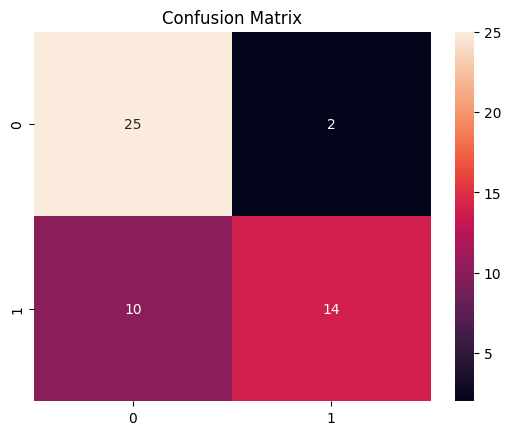

In [ ]:
# Import confusion matrix function to evaluate classification performance
from sklearn.metrics import confusion_matrix

# Import seaborn for visualization of the confusion matrix
import seaborn as sns

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Generate confusion matrix using true labels and predicted labels
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix using a heatmap
sns.heatmap(cm, annot=True, fmt='d')

# Add title to the plot
plt.title("Confusion Matrix")

# Display the plot
plt.show()

Experiment 1: Baseline Model (SVM)

In the first experiment, a baseline model was implemented using Support Vector Machine (SVM) without applying any additional image filtering techniques. All images were resized to 100×100 pixels and normalized to scale pixel values between 0 and 1. The dataset was split into 80% training and 20% testing data. The SVM classifier was trained on the processed features and evaluated using standard performance metrics including accuracy, precision, recall, and F1-score.


In [ ]:
# Import function to split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% training data, 20% testing data
# random_state ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(
    processed_data, labels, test_size=0.2, random_state=42
)

In [95]:
from sklearn.svm import SVC

model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

In [96]:
y_pred = model.predict(X_test)

In [ ]:
# Import evaluation metrics for classification performance
from sklearn.metrics import (
    accuracy_score,   # Overall correctness of predictions
    precision_score,  # How many predicted positives are actually correct
    recall_score,     # How many actual positives are correctly identified
    f1_score          # Balance between precision and recall
)

# Print overall accuracy of the model
print("Accuracy:", accuracy_score(y_test, y_pred))

# Print precision (weighted average across classes)
print("Precision:", precision_score(y_test, y_pred, average='weighted'))

# Print recall (weighted average across classes)
print("Recall:", recall_score(y_test, y_pred, average='weighted'))

# Print F1 score (weighted average across classes)
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.7647058823529411
Precision: 0.7899159663865546
Recall: 0.7647058823529411
F1 Score: 0.7563567362428841


Experiment 2: Gaussian Blur with SVM

In [98]:
import cv2
import numpy as np

processed_data_blur = []

for img in data:
    # Apply Gaussian Blur
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    
    # Resize
    resized = cv2.resize(blurred, (100, 100))
    
    # Normalize
    normalized = resized / 255.0
    
    # Flatten
    flattened = normalized.flatten()
    
    processed_data_blur.append(flattened)

processed_data_blur = np.array(processed_data_blur)

print("Gaussian Blur Preprocessing Completed")
print("Shape:", processed_data_blur.shape)

Gaussian Blur Preprocessing Completed
Shape: (253, 10000)


In [ ]:
# Import function to split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Split the blurred processed dataset into training and testing sets
# 80% data is used for training and 20% is used for testing
# random_state ensures the same split every time for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    processed_data_blur, labels, test_size=0.2, random_state=42
)

In [100]:
from sklearn.svm import SVC

model = SVC(kernel='linear')
model.fit(X_train, y_train)

print("SVM Training Completed (Gaussian Blur)")

SVM Training Completed (Gaussian Blur)


In [ ]:
# Import evaluation metrics for classification performance
from sklearn.metrics import (
    accuracy_score,   # Measures overall correctness of predictions
    precision_score,  # Measures correctness of positive predictions
    recall_score,     # Measures ability to find all positive samples
    f1_score          # Harmonic mean of precision and recall
)

# Generate predictions using the trained model
y_pred = model.predict(X_test)

# Print accuracy of the model
print("Accuracy:", accuracy_score(y_test, y_pred))

# Print precision using weighted average (handles class imbalance)
print("Precision:", precision_score(y_test, y_pred, average='weighted'))

# Print recall using weighted average (handles class imbalance)
print("Recall:", recall_score(y_test, y_pred, average='weighted'))

# Print F1-score using weighted average (balance between precision & recall)
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.7254901960784313
Precision: 0.7349970291146761
Recall: 0.7254901960784313
F1 Score: 0.719607843137255


Experiment 3: Random Forest Classifier

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    processed_data, labels, test_size=0.2, random_state=42
)

In [103]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

print("Random Forest Training Completed")

Random Forest Training Completed


In [104]:
y_pred = rf_model.predict(X_test)

print("Prediction Completed")

Prediction Completed


In [105]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.8235294117647058
Precision: 0.8346555727554179
Recall: 0.8235294117647058
F1 Score: 0.8207470611421548


Experiment 4: KNN (k=5)

In [119]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [121]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

knn = KNeighborsClassifier(n_neighbors=5)

# Train
knn.fit(X_train_flat, y_train)

# Predict
y_pred_knn = knn.predict(X_test_flat)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_knn, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_knn, average='weighted'))

Accuracy: 0.7647058823529411
Precision: 0.7831932773109243
Recall: 0.7647058823529411
F1 Score: 0.7630718954248367


Experiment 5: Logistic Regression

In [123]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [ ]:
# Import Logistic Regression model for classification
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics to measure model performance
from sklearn.metrics import (
    accuracy_score,   # Overall correctness of predictions
    precision_score,  # Precision of predictions
    recall_score,     # Recall of predictions
    f1_score          # Balanced performance metric
)

# Create Logistic Regression model with increased iterations for convergence
log_model = LogisticRegression(max_iter=1000)

# Train the Logistic Regression model on flattened training data
log_model.fit(X_train_flat, y_train)

# Predict labels for test data
y_pred_log = log_model.predict(X_test_flat)

# Evaluate model accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_log))

# Evaluate precision (weighted to handle class imbalance)
print("Precision:", precision_score(y_test, y_pred_log, average='weighted'))

# Evaluate recall (weighted average)
print("Recall:", recall_score(y_test, y_pred_log, average='weighted'))

# Evaluate F1 score (balance between precision and recall)
print("F1 Score:", f1_score(y_test, y_pred_log, average='weighted'))

Accuracy: 0.803921568627451
Precision: 0.8098671726755217
Recall: 0.803921568627451
F1 Score: 0.8017702378757146
